# 01 — Dataset Preprocessing

Dataset: **Resume Entities for NER** (Kaggle — Dataturks)  
220 resumes annotated manually with 11 entity types.

This notebook covers:
1. What the raw data looks like
2. Problems found in the raw data
3. Cleaning steps applied and why
4. Saving the cleaned train/test splits

In [1]:
import json
import re
import random
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

colors = ['#4361ee', '#3a86ff', '#ff006e', '#fb5607', '#8338ec',
          '#06d6a0', '#118ab2', '#ffd166', '#ef476f', '#073b4c']

In [2]:
data_path = Path('../data/raw/Entity Recognition in Resumes.json')

raw_data = []
with open(data_path, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            raw_data.append(json.loads(line))

print(f'Total resumes loaded: {len(raw_data)}')
print()

sample = raw_data[0]
print('First 300 characters of resume content:')
print(sample['content'][:300])

Total resumes loaded: 220

First 300 characters of resume content:
Abhishek Jha
Application Development Associate - Accenture

Bengaluru, Karnataka - Email me on Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a

• To work for an organization which provides me the opportunity to improve my skills
and knowledge for my individual and company's growth in best possibl


In [3]:
print('Annotation structure (first 3 entities):')
print()
for ann in sample['annotation'][:3]:
    point = ann['points'][0]
    print(f"  Label : {ann['label']}")
    print(f"  Start : {point['start']}")
    print(f"  End   : {point['end']}  <-- inclusive end, spaCy needs end+1")
    print(f"  Text  : {point['text'][:50].strip()!r}")
    print()

Annotation structure (first 3 entities):

  Label : ['Skills']
  Start : 1295
  End   : 1621  <-- inclusive end, spaCy needs end+1
  Text  : '• Programming language: C, C++, Java\n• Oracle Peo'

  Label : ['Skills']
  Start : 993
  End   : 1153  <-- inclusive end, spaCy needs end+1
  Text  : 'C (Less than 1 year), Database (Less than 1 year),'

  Label : ['College Name']
  Start : 939
  End   : 956  <-- inclusive end, spaCy needs end+1
  Text  : 'Kendriya Vidyalaya'



In [4]:
word_counts = [len(r['content'].split()) for r in raw_data]

label_counts = Counter()
for r in raw_data:
    for ann in (r.get('annotation') or []):
        for lbl in (ann.get('label') or []):
            label_counts[lbl.strip()] += 1

total_overlaps = 0
total_offset_errors = 0

for r in raw_data:
    text = r.get('content', '')
    spans = []
    for ann in (r.get('annotation') or []):
        for pt in (ann.get('points') or []):
            s, e = pt['start'], pt['end']
            if text[s:e+1].strip() != pt.get('text', '').strip():
                total_offset_errors += 1
            spans.append((s, e))
    for i in range(len(spans)):
        for j in range(i + 1, len(spans)):
            s1, e1 = spans[i]
            s2, e2 = spans[j]
            if s1 <= e2 and s2 <= e1:
                total_overlaps += 1

print('Data quality summary:')
print(f'  Total resumes           : {len(raw_data)}')
print(f'  Too short (< 50 words)  : {sum(1 for w in word_counts if w < 50)}  → will be dropped')
print(f'  Overlapping span pairs  : {total_overlaps}  → crashes spaCy training')
print(f'  Offset mismatches       : {total_offset_errors}  → caused by \\r\\n line endings')
print(f'  Average words / resume  : {int(sum(word_counts) / len(word_counts))}')

Data quality summary:
  Total resumes           : 220
  Too short (< 50 words)  : 15  → will be dropped
  Overlapping span pairs  : 117  → crashes spaCy training
  Offset mismatches       : 223  → caused by \r\n line endings
  Average words / resume  : 517


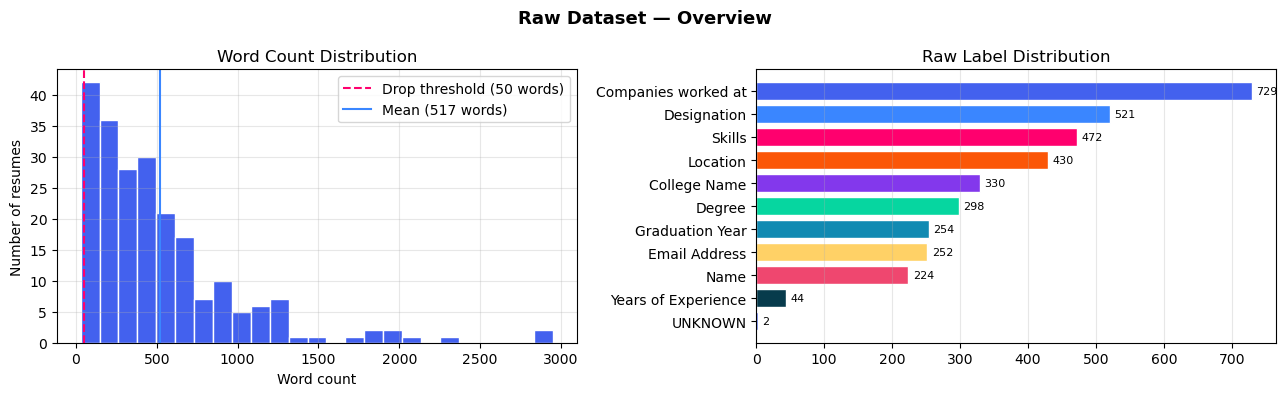

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Raw Dataset — Overview', fontweight='bold', fontsize=13)

axes[0].hist(word_counts, bins=25, color=colors[0], edgecolor='white')
axes[0].axvline(50, color=colors[2], linestyle='--',
                label='Drop threshold (50 words)')
axes[0].axvline(int(sum(word_counts) / len(word_counts)), color=colors[1],
                linestyle='-', label=f'Mean ({int(sum(word_counts)/len(word_counts))} words)')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of resumes')
axes[0].legend()
axes[0].grid(alpha=0.3)

lbls, cnts = zip(*label_counts.most_common())
bars = axes[1].barh(lbls, cnts, color=colors[:len(lbls)], edgecolor='white')
axes[1].bar_label(bars, padding=3, fontsize=8)
axes[1].set_title('Raw Label Distribution')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [6]:
import string

LABEL_MAP = {
    'name':                'NAME',
    'college name':        'COLLEGE_NAME',
    'degree':              'DEGREE',
    'graduation year':     'GRADUATION_YEAR',
    'years of experience': 'YEARS_OF_EXPERIENCE',
    'companies worked at': 'COMPANIES_WORKED_AT',
    'designation':         'DESIGNATION',
    'skills':              'SKILLS',
    'location':            'LOCATION',
    'email address':       'EMAIL_ADDRESS',
    'links':               'LINKS',
    'unknown':             None,   # 2 occurrences in the dataset — we drop these
}

def clean_text(text):
    text = text.replace('\r\n', '\n').replace('\r', '\n')

    text = text.replace('\xa0', ' ')

    text = text.replace('&amp;', '&').replace('&lt;', '<').replace('&gt;', '>')

    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()

def extract_spans(annotation, text):
    spans = []
    for ann in (annotation or []):
        labels = ann.get('label', [])
        if isinstance(labels, str):
            labels = [labels]
        for pt in ann.get('points', []):
            start = pt['start']
            end   = pt['end'] + 1

            start = max(0, min(start, len(text)))
            end   = max(0, min(end,   len(text)))

            if start >= end:
                continue

            span_text = text[start:end]

            stripped = span_text.strip()
            if not stripped:
                continue

            leading  = len(span_text) - len(span_text.lstrip())
            trailing = len(span_text) - len(span_text.rstrip())
            start    = start + leading
            end      = end - trailing if trailing > 0 else end

            if start >= end:
                continue

            if text[start] in string.punctuation:
                continue

            for lbl in labels:
                mapped = LABEL_MAP.get(lbl.strip().lower())
                if mapped:
                    spans.append((start, end, mapped))
    return spans

def remove_overlaps(spans):
    sorted_spans = sorted(spans, key=lambda s: s[1] - s[0], reverse=True)
    kept = []
    for span in sorted_spans:
        s, e, _ = span
        has_overlap = any(s < ek and e > sk for sk, ek, _ in kept)
        if not has_overlap:
            kept.append(span)
    return sorted(kept, key=lambda s: s[0])


In [7]:
processed = []
dropped   = 0

for record in raw_data:
    text = clean_text(record.get('content', ''))

    if len(text.split()) < 50:
        dropped += 1
        continue

    spans = extract_spans(record.get('annotation'), text)
    spans = remove_overlaps(spans)

    processed.append({
        'text':     text,
        'entities': [[s, e, lbl] for s, e, lbl in spans]
    })

print(f'Valid records   : {len(processed)}')
print(f'Dropped records : {dropped}  (< 50 words)')

Valid records   : 205
Dropped records : 15  (< 50 words)


In [8]:
random.seed(42)
random.shuffle(processed)

split_index = int(len(processed) * 200 / 220)
train_data  = processed[:split_index]
test_data   = processed[split_index:]

print(f'Train : {len(train_data)} resumes')
print(f'Test  : {len(test_data)} resumes')

Train : 186 resumes
Test  : 19 resumes


In [9]:
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

with open(output_dir / 'train_data.json', 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False)

with open(output_dir / 'test_data.json', 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False)

print('Saved: train_data.json and test_data.json → data/processed/')

Saved: train_data.json and test_data.json → data/processed/


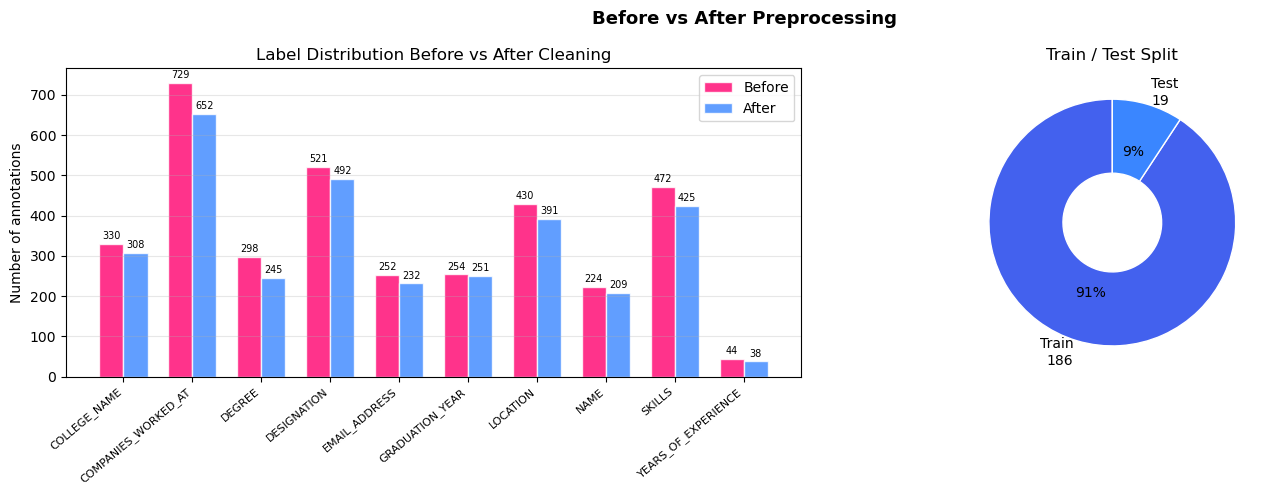

In [10]:
label_after = Counter()
for item in processed:
    for _, _, lbl in item['entities']:
        label_after[lbl] += 1

label_before_mapped = {}
for lbl, count in label_counts.items():
    canonical = LABEL_MAP.get(lbl.lower())
    if canonical:
        label_before_mapped[canonical] = label_before_mapped.get(canonical, 0) + count

all_labels  = sorted(label_after.keys())
x = np.arange(len(all_labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Before vs After Preprocessing', fontweight='bold', fontsize=13)

before_vals = [label_before_mapped.get(l, 0) for l in all_labels]
after_vals  = [label_after[l]               for l in all_labels]

b1 = axes[0].bar(x - w/2, before_vals, w, label='Before', color=colors[2], alpha=0.8, edgecolor='white')
b2 = axes[0].bar(x + w/2, after_vals,  w, label='After',  color=colors[1], alpha=0.8, edgecolor='white')
axes[0].bar_label(b1, fontsize=7, padding=2)
axes[0].bar_label(b2, fontsize=7, padding=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_labels, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel('Number of annotations')
axes[0].set_title('Label Distribution Before vs After Cleaning')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

axes[1].pie(
    [len(train_data), len(test_data)],
    labels=[f'Train\n{len(train_data)}', f'Test\n{len(test_data)}'],
    colors=[colors[0], colors[1]],
    autopct='%1.0f%%',
    wedgeprops={'edgecolor': 'white', 'width': 0.6},
    startangle=90
)
axes[1].set_title('Train / Test Split')

plt.tight_layout()
plt.show()